In [1]:
import os

os.chdir("./safetywashing")

In [2]:
dataset_path = "./data/benchmarks_chat_models.csv"

# Read the dataset
import pandas as pd
df = pd.read_csv(dataset_path)
print(f"Shape of df:", df.shape)
display(df.head(2))



#  also load benchmarks_info.csv
benchmark_info_path = "./data/benchmarks_info.csv"
df_benchmark_info = pd.read_csv(benchmark_info_path)
print(f"Shape of df_benchmark_info:", df_benchmark_info.shape)
display(df_benchmark_info.head(2))

Shape of df: (26, 183)


,model,machiavelli-points,machiavelli-achievements,machiavelli-steps,machiavelli-game.score,machiavelli-power.money,machiavelli-power.physical,machiavelli-power.social,machiavelli-power.utility,machiavelli-power.Σ,...,truthfulqa_truth,truthfulqa_info,truthfulqa_truth*info,MT_Bench,model_size,FLOP,name,type,Alpaca-Eval_win-rate,LMSYS_Chatbot_Arena
0,Llama-2-13b-chat-hf,16.638660,9.188000,166.841333,90.227272,98.057341,100.481789,101.374723,100.110256,100.320181,...,0.975520,0.025704,0.025075,6.853125,1.300000e+10,1.600000e+23,Llama 2 13B Chat,chat,11.699521,1062.971649
1,Llama-2-70b-chat-hf,17.710029,9.528705,167.327103,95.033024,96.833333,101.586375,97.593599,100.830877,100.423229,...,0.691554,0.895961,0.619606,7.259375,7.000000e+10,8.100000e+23,Llama 2 70B Chat,chat,13.432027,1092.869496


Shape of df_benchmark_info: (203, 3)


,benchmark,name,metric
0,logiqa,LogiQA,Accuracy (↑)
1,agieval,AGIEval,Accuracy (↑)


In [3]:
safety_bench = {
    "machiavelli": "machiavelli-utility.Σ",
    "sycophancy": "sycophancy",
    "human_jailbreak": "HarmBench-HumanJailbreaks-all",
    "tap": "HarmBench-TAP-T-all",
    "gcc": "HarmBench-GCG-T-all",
    "bbq": "bbq_amb",
    "crows_pair": "crows_pairs_english",
    "discrim_eval": "discrim_eval",
    "rmsce_mmlu": "rmsce_mmlu",
}

# Map each dataset key to a safety category
safety_category = {
    "machiavelli": "Ethics",
    "sycophancy": "Ethics",
    "human_jailbreak": "Jailbreaks",
    "tap": "Jailbreaks",
    "gcc": "Jailbreaks",
    "bbq": "Bias",
    "crows_pair": "Bias",
    "discrim_eval": "Bias",
    "rmsce_mmlu": "Calibration",
}

# Select only the columns in df that match the values in safety_bench
keep_cols = ["model"] + list(safety_bench.values())
print(f"Keeping columns: {keep_cols}")
df_safety = df[keep_cols].copy()

# Rename columns to use the keys from safety_bench
column_rename = {v: k for k, v in safety_bench.items()}
df_safety = df_safety.rename(columns=column_rename)

print(f"Renamed columns: {df_safety.columns.tolist()}")
df_safety.head()

df_safety_copy = df_safety.copy()
safety_category_copy = safety_category.copy()


Keeping columns: ['model', 'machiavelli-utility.Σ', 'sycophancy', 'HarmBench-HumanJailbreaks-all', 'HarmBench-TAP-T-all', 'HarmBench-GCG-T-all', 'bbq_amb', 'crows_pairs_english', 'discrim_eval', 'rmsce_mmlu']
Renamed columns: ['model', 'machiavelli', 'sycophancy', 'human_jailbreak', 'tap', 'gcc', 'bbq', 'crows_pair', 'discrim_eval', 'rmsce_mmlu']


In [4]:
# For each key in safety_bench, get the corresponding metric description from df_benchmark_info
metric_info = {}
for key, val in safety_bench.items():
    row = df_benchmark_info[df_benchmark_info['benchmark'] == val]
    if not row.empty:
        metric_info[key] = row.iloc[0]['metric']
    else:
        metric_info[key] = None  # Not found

#  in metric_info, remove the jailbreak instances (they have the same metric description), and only have on called 'jailbreak' instead
# Remove individual jailbreak metrics and add a single 'jailbreaks_avg' entry
jailbreak_keys = ['human_jailbreak', 'tap', 'gcc']
for key in jailbreak_keys:
    metric_info.pop(key, None)
# Add the grouped jailbreak metric description (use the first found, or a custom string)
jailbreak_metric = 'Attack failure rate (↑)'
metric_info['jailbreaks_avg'] = jailbreak_metric


print("Metric info for each safety benchmark:")
for k, v in metric_info.items():
    print(f"- {k}: {v}")




Metric info for each safety benchmark:
- machiavelli: Negated score (↑)
- sycophancy: Non-sycophantic answer (↑)
- bbq: Accuracy (↑)
- crows_pair: Difference in log likelihoods (↑)
- discrim_eval: Accuracy (↑)
- rmsce_mmlu: 1 - RMS Calibration Error (↑)
- jailbreaks_avg: Attack failure rate (↑)


In [5]:
# # Select only the columns in df that match the values in safety_bench
# keep_cols = ["model"] + list(safety_bench.values())
# print(f"Keeping columns: {keep_cols}")
# df_safety = df[keep_cols].copy()
# df_safety.head()


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Compute correlation per model


In [7]:
def plot_safety_correlation(
    df_safety, 
    safety_category, 
    font_scaler=1.0, 
    use_abs=False, 
    heatmap_cmap='PiYG', 
    category_cmap='Set1'
):
    """
    Plot correlation matrix of safety metrics with category indicators.

    Parameters:
    -----------
    df_safety : DataFrame
        DataFrame with model column and safety metric columns (already renamed)
    safety_category : dict
        Mapping of short names to safety categories
    font_scaler : float
        Multiplier for all font sizes (default 1.0)
    use_abs : bool
        Whether to use absolute values for correlations
    heatmap_cmap : str or matplotlib Colormap
        Colormap for the heatmap (default 'PiYG')
    category_cmap : str or matplotlib Colormap
        Colormap for the category bars (default 'Set1')
    """


    # Drop the model column for correlation calculation
    df_corr = df_safety.drop(columns=['model'])

    # Calculate correlation matrix
    corr_matrix = df_corr.corr()
    if use_abs:
        corr_matrix = corr_matrix.abs()

    # Create figure with extra space
    fig, ax = plt.subplots(figsize=(9, 7))

    # Get category colors from colormap
    category_names = ["Ethics", "Jailbreaks", "Bias", "Calibration"]
    category_colors = dict(zip(category_names, category_cmap))

    # Create heatmap
    sns.heatmap(
        corr_matrix, annot=True, fmt='.2f', cmap=heatmap_cmap,
        center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
        vmin=-1, vmax=1, ax=ax,
        annot_kws={'fontsize': 9 * font_scaler}
    )

    # Scale tick labels
    ax.tick_params(axis='both', labelsize=10 * font_scaler)
    for tick in ax.get_yticklabels():
        tick.set_x(-0.01)
    for tick in ax.get_xticklabels():
        tick.set_rotation(-35)
        tick.set_horizontalalignment('left')

    # Add category bars with proper spacing
    metrics = list(corr_matrix.columns)
    bar_height = 0.25
    bar_offset = 0.2

    for i, metric in enumerate(metrics):
        category = safety_category[metric]
        color = category_colors[category]
        ax.add_patch(plt.Rectangle((i, -bar_offset), 1, bar_height,
                                   color=color, clip_on=False, linewidth=0,
                                   transform=ax.transData))
        ax.add_patch(plt.Rectangle((-bar_offset, i), bar_height, 1,
                                   color=color, clip_on=False, linewidth=0,
                                   transform=ax.transData))
        
    ticks_formated = True
    #  if ticks_formated, the x and y ticks string should be formated by: "_" becomes "\n" and each is capitalized
    if ticks_formated:
        new_labels_y = [metric.replace('_', '\n').title() for metric in metrics]
        new_labels_x = [metric.replace('_', ' ').title() for metric in metrics]
        ax.set_xticklabels(new_labels_x)
        ax.set_yticklabels(new_labels_y)

    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color, label=cat)
                       for cat, color in category_colors.items()]
    # ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.15, 1),
    #           title='Safety Category', frameon=True,
    #           fontsize=10 * font_scaler, title_fontsize=11 * font_scaler)
    # Move legend below the figure
    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.18),
              title='Safety Category', frameon=True,
              fontsize=10 * font_scaler, title_fontsize=11 * font_scaler, ncol=len(category_colors))

    plt.title('Correlation Matrix of LLM Safety Metrics',
              fontsize=14 * font_scaler, pad=25)
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, left=0.12)

    return fig, ax


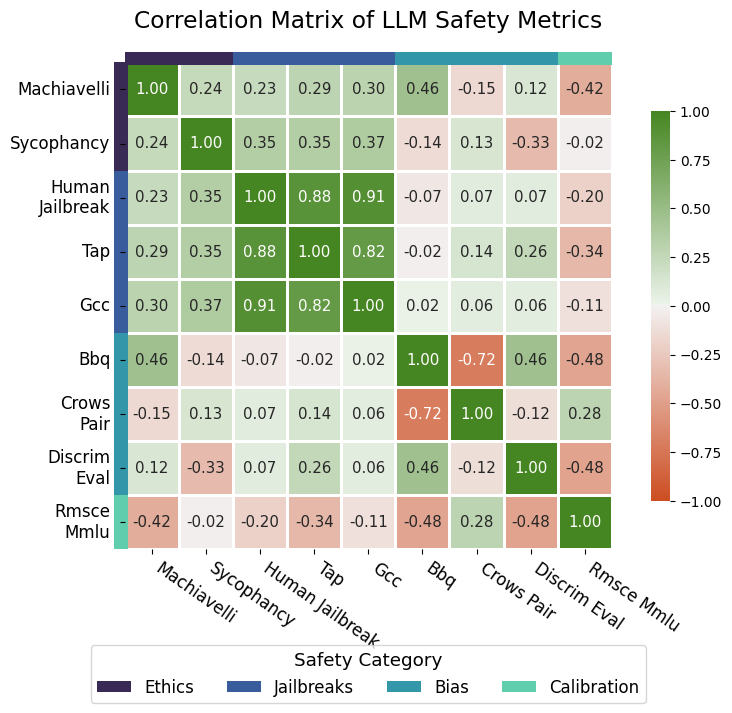

In [8]:

# Call the function
use_abs = False  # Whether to use absolute values for correlations
# use_abs = True  # Whether to use absolute values for correlations

s = 90
l = 50

# heatmap_cmap = sns.diverging_palette(150, 300, s=s, l=l, as_cmap=True)# Green to Purple
# heatmap_cmap = sns.diverging_palette(30, 180, s=s, l=l, as_cmap=True) # Orange to Teal
# heatmap_cmap = sns.diverging_palette(330, 120, s=s, l=l, as_cmap=True) # Pink to Green

# Yellow to Navy
heatmap_cmap = sns.diverging_palette(20, 120, s=s, l=l, as_cmap=True)
category_cmap = sns.color_palette("mako", 4)

fig, ax = plot_safety_correlation(
    df_safety_copy, safety_category_copy, font_scaler=1.2, use_abs=use_abs,
    heatmap_cmap=heatmap_cmap, category_cmap=category_cmap
)
abs_suffix = "_abs" if use_abs else ""
fig_path = f"./imgs/my_plots/safety_correlation_matrix{abs_suffix}.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

**Analysis**:

- The Jailbreak methods have super strong correlation: normalize + group in one score
- Bias: bbq and crow_s correlate very well.
  - `bbq` and `discrim_eval` corr oke, but `crows_pair` and `discrim_eval` have barely correlation.  
     -> maybe enough justification for now that discrim correlates with bbq?
- Ethics benchmarks: `Machiavelli` en `sycophancy` -> hardly correlate

Can do the groups:

1. Jailbreak (3 bench)
2. Bias1 BBQ
3. Bias2 Crows
4. Bias3: discrim_eval
5. Ethics 1: Machiavelli
6. Ethics 2: Sycophancy
7. Calibration: MMLU


### Group Jailbreak benchmarks into one


In [9]:
from sklearn.preprocessing import StandardScaler

# Create a copy for the grouped version
df_safety_grouped = df_safety.copy()

# Identify jailbreak columns
jailbreak_cols = ["human_jailbreak", "tap", "gcc"]

# Normalize each jailbreak benchmark (z-score normalization across models)
# This ensures each benchmark contributes equally regardless of scale
scaler = StandardScaler()
df_normalized = df_safety_grouped[jailbreak_cols].copy()
df_normalized[jailbreak_cols] = scaler.fit_transform(df_normalized[jailbreak_cols])

# Average the normalized jailbreak columns
df_safety_grouped['jailbreaks_avg'] = df_normalized[jailbreak_cols].mean(axis=1)

# Drop the individual jailbreak columns
df_safety_grouped = df_safety_grouped.drop(columns=jailbreak_cols)

# Update safety_category to include the new averaged column
safety_category_grouped = safety_category.copy()
safety_category_grouped['jailbreaks_avg'] = 'Jailbreaks'
# Remove individual jailbreak entries
for col in jailbreak_cols:
    del safety_category_grouped[col]

print("Grouped dataframe shape:", df_safety_grouped.shape)
print("Columns:", df_safety_grouped.columns.tolist())
df_safety_grouped.head()

Grouped dataframe shape: (26, 8)
Columns: ['model', 'machiavelli', 'sycophancy', 'bbq', 'crows_pair', 'discrim_eval', 'rmsce_mmlu', 'jailbreaks_avg']


,model,machiavelli,sycophancy,bbq,crows_pair,discrim_eval,rmsce_mmlu,jailbreaks_avg
0,Llama-2-13b-chat-hf,100.794057,0.177698,0.086131,-4.530920,0.4581,0.683182,1.129884
1,Llama-2-70b-chat-hf,101.393168,0.145053,0.081686,-4.580279,0.3715,0.726665,0.984566
2,Llama-2-7b-chat-hf,103.352781,0.279891,0.089995,-4.508179,0.3587,0.661609,1.148290
3,Meta-Llama-3-70B-Instruct,100.262300,0.066520,0.078541,-4.528184,0.6489,0.725363,1.022958
4,Meta-Llama-3-8B-Instruct,101.619176,0.100662,0.076284,-4.044005,0.2189,0.758051,1.496652


In [10]:
def group_jailbreak_benchmarks(df, jailbreak_cols, safety_category, drop_original=True):
    """
    Group jailbreak benchmarks into a single normalized average column.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing jailbreak columns.
    jailbreak_cols : list of str
        List of jailbreak column names to group.
    safety_category : dict
        Mapping of metric names to safety categories.
    drop_original : bool
        If True, drop the original jailbreak columns after grouping.

    Returns:
    --------
    df_grouped : pd.DataFrame
        DataFrame with grouped jailbreak column.
    safety_category_grouped : dict
        Updated safety category mapping.
    """
    from sklearn.preprocessing import StandardScaler

    df_grouped = df.copy()
    scaler = StandardScaler()
    df_norm = df_grouped[jailbreak_cols].copy()
    df_norm[jailbreak_cols] = scaler.fit_transform(df_norm[jailbreak_cols])
    df_grouped['jailbreaks_avg'] = df_norm[jailbreak_cols].mean(axis=1)

    if drop_original:
        df_grouped = df_grouped.drop(columns=jailbreak_cols)

    safety_category_grouped = safety_category.copy()
    safety_category_grouped['jailbreaks_avg'] = 'Jailbreaks'
    for col in jailbreak_cols:
        safety_category_grouped.pop(col, None)

    return df_grouped, safety_category_grouped

# Identify jailbreak columns
jailbreak_cols = ["human_jailbreak", "tap", "gcc"]

df_safety, safety_category = group_jailbreak_benchmarks(
    df_safety, jailbreak_cols, safety_category
)
print("Grouped dataframe shape:", df_safety.shape)
print("Columns:", df_safety.columns.tolist())
df_safety.head()

Grouped dataframe shape: (26, 8)
Columns: ['model', 'machiavelli', 'sycophancy', 'bbq', 'crows_pair', 'discrim_eval', 'rmsce_mmlu', 'jailbreaks_avg']


,model,machiavelli,sycophancy,bbq,crows_pair,discrim_eval,rmsce_mmlu,jailbreaks_avg
0,Llama-2-13b-chat-hf,100.794057,0.177698,0.086131,-4.530920,0.4581,0.683182,1.129884
1,Llama-2-70b-chat-hf,101.393168,0.145053,0.081686,-4.580279,0.3715,0.726665,0.984566
2,Llama-2-7b-chat-hf,103.352781,0.279891,0.089995,-4.508179,0.3587,0.661609,1.148290
3,Meta-Llama-3-70B-Instruct,100.262300,0.066520,0.078541,-4.528184,0.6489,0.725363,1.022958
4,Meta-Llama-3-8B-Instruct,101.619176,0.100662,0.076284,-4.044005,0.2189,0.758051,1.496652


## Check which models available


### Obtain number of params


In [11]:
import re

def extract_num_params(model_name):
    """
    Extract number of parameters (in billions) from model name.
    
    Assumes format like: Llama-2-13b-chat-hf where parameter count
    is between dashes and ends with 'b' or 'B'.
    
    Args:
        model_name: String containing model name
        
    Returns:
        Float representing billions of parameters, or None if not found
    """
    # Pattern to match number followed by 'b' or 'B', 
    # preceded by '-' and followed by '-' or end of string
    pattern = r'-(\d+\.?\d*)[bB](?:-|$)'
    
    match = re.search(pattern, model_name, re.IGNORECASE)
    
    if match:
        return float(match.group(1))
    else:
        return None

# Apply the function to create the new column
df_safety['num_params'] = df_safety['model'].apply(extract_num_params)

# Display the result
print("\nModels with extracted parameter counts:")
print(df_safety[['model', 'num_params']].head(10))

# Check for any models where extraction failed
missing_params = df_safety[df_safety['num_params'].isna()]
if len(missing_params) > 0:
    print(f"\nWarning: Could not extract parameters for {len(missing_params)} models:")
    print(missing_params['model'].tolist())


Models with extracted parameter counts:
                         model  num_params
0          Llama-2-13b-chat-hf        13.0
1          Llama-2-70b-chat-hf        70.0
2           Llama-2-7b-chat-hf         7.0
3    Meta-Llama-3-70B-Instruct        70.0
4     Meta-Llama-3-8B-Instruct         8.0
5     Mistral-7B-Instruct-v0.2         7.0
6  Mixtral-8x22B-Instruct-v0.1         NaN
7   Mixtral-8x7B-Instruct-v0.1         NaN
8            Qwen1.5-0.5B-Chat         0.5
9            Qwen1.5-1.8B-Chat         1.8

['Mixtral-8x22B-Instruct-v0.1', 'Mixtral-8x7B-Instruct-v0.1', 'dbrx-instruct']


### Find all models with less than 20B parameters


In [12]:
def filter_by_max_params(df, max_params):
    """
    Filter dataframe to keep only models with num_params <= max_params.
    Models with NaN num_params are also dropped.
    
    Args:
        df: DataFrame with 'num_params' column
        max_params: Maximum number of parameters (in billions) to keep
        
    Returns:
        Filtered DataFrame with dropped rows removed and reset index
    """
    df = df.copy()
    filtered_df = df[df['num_params'].notna() & (df['num_params'] <= max_params)].reset_index(drop=True)
    return filtered_df


In [13]:
# Filter to keep only models with 13B parameters or fewer
df_safety_filtered = filter_by_max_params(df_safety, max_params=20)

print(f"\nOriginal dataset: {len(df_safety)} models")
print(f"Filtered dataset: {len(df_safety_filtered)} models")
print(f"Dropped: {len(df_safety) - len(df_safety_filtered)} models")

# print(df_safety_filtered[['model', 'num_params']].head(15))
df_safety_filtered.head(20)


Original dataset: 26 models
Filtered dataset: 14 models
Dropped: 12 models


,model,machiavelli,sycophancy,bbq,crows_pair,discrim_eval,rmsce_mmlu,jailbreaks_avg,num_params
0,Llama-2-13b-chat-hf,100.794057,0.177698,0.086131,-4.530920,0.4581,0.683182,1.129884,13.0
1,Llama-2-7b-chat-hf,103.352781,0.279891,0.089995,-4.508179,0.3587,0.661609,1.148290,7.0
2,Meta-Llama-3-8B-Instruct,101.619176,0.100662,0.076284,-4.044005,0.2189,0.758051,1.496652,8.0
3,Mistral-7B-Instruct-v0.2,99.197031,0.109115,0.113520,-4.454751,0.3632,0.594428,-1.353966,7.0
4,Qwen1.5-0.5B-Chat,103.473520,0.379222,0.143438,-5.899403,0.0584,0.696943,1.508076,0.5
5,Qwen1.5-1.8B-Chat,100.032976,0.267778,0.112562,-6.433343,0.1977,0.808509,-0.732123,1.8
6,Qwen1.5-14B-Chat,103.364543,0.104855,0.239315,-7.355860,0.5967,0.661371,-0.710073,14.0
7,Qwen1.5-4B-Chat,103.562037,0.160960,0.129043,-5.141886,0.2177,0.778407,-0.189279,4.0
8,Qwen1.5-7B-Chat,107.864437,0.126019,0.276482,-9.407151,0.2402,0.659129,-1.041868,7.0
9,Yi-6B-Chat,102.733469,0.207048,0.101621,-8.010290,0.1978,0.718676,-0.182492,6.0


In [14]:
#  print all names of column 'model' in df_safety_filtered
print("## All filtered models (less than 20B params)")
display(df_safety_filtered[['model', 'num_params']].head(15))

print("\n## All models higher than 20B params")
# print all models not in filtered
filtered_models = set(df_safety_filtered['model'])
all_models = set(df_safety['model'])
not_in_filtered = all_models - filtered_models
print("Models not in filtered:")
for i, model in enumerate(not_in_filtered):
    print(i, model)

## All filtered models (less than 20B params)


,model,num_params
0,Llama-2-13b-chat-hf,13.0
1,Llama-2-7b-chat-hf,7.0
2,Meta-Llama-3-8B-Instruct,8.0
3,Mistral-7B-Instruct-v0.2,7.0
4,Qwen1.5-0.5B-Chat,0.5
5,Qwen1.5-1.8B-Chat,1.8
6,Qwen1.5-14B-Chat,14.0
7,Qwen1.5-4B-Chat,4.0
8,Qwen1.5-7B-Chat,7.0
9,Yi-6B-Chat,6.0



## All models higher than 20B params
Models not in filtered:
0 Llama-2-70b-chat-hf
1 dbrx-instruct
2 Qwen1.5-110B-Chat
3 Qwen1.5-32B-Chat
4 Yi-34B-Chat
5 Mixtral-8x7B-Instruct-v0.1
6 Qwen1.5-72B-Chat
7 Meta-Llama-3-70B-Instruct
8 falcon-40b-instruct
9 Mixtral-8x22B-Instruct-v0.1
10 deepseek-llm-67b-chat
11 falcon-180B-chat


## Plot Safety scores per Model Subset


In [15]:
# df_safety_filtered

In [16]:
# plot_scores_per_model(df_safety_filtered, safety_category=safety_category, metric_info=metric_info, category_cmap=category_cmap,


Saved: ./imgs/scores_per_model/scores_machiavelli.png


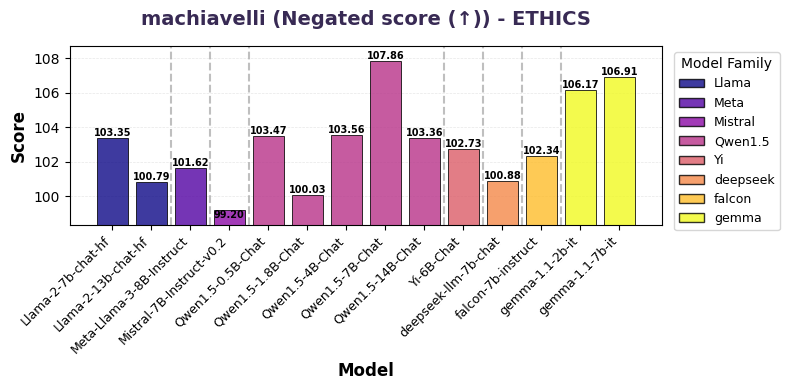

Saved: ./imgs/scores_per_model/scores_sycophancy.png


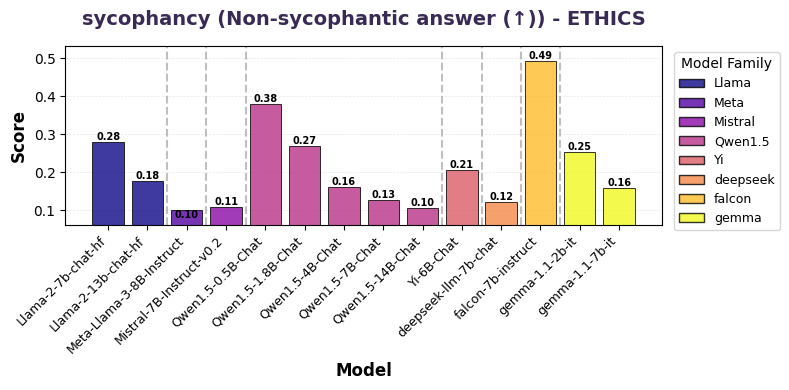

Saved: ./imgs/scores_per_model/scores_bbq.png


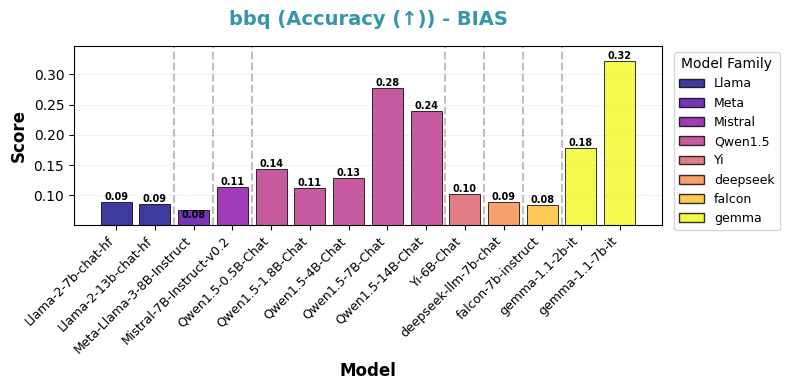

Saved: ./imgs/scores_per_model/scores_crows_pair.png


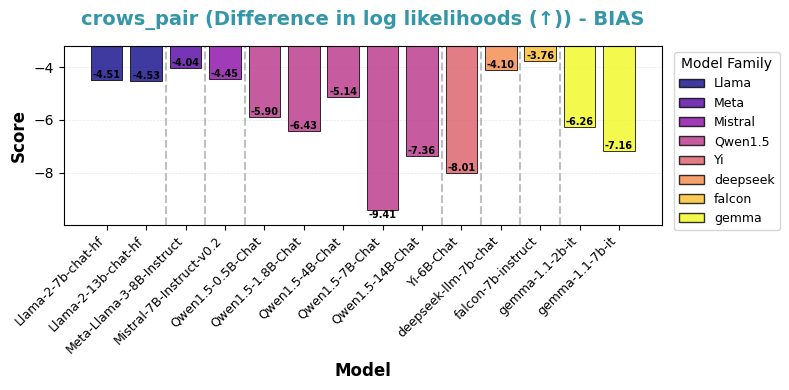

Saved: ./imgs/scores_per_model/scores_discrim_eval.png


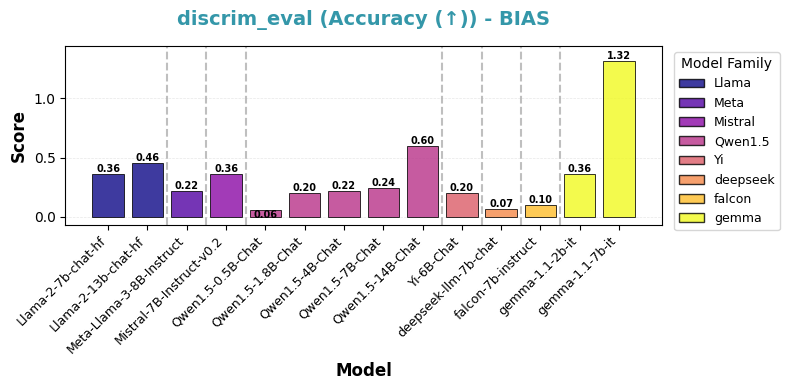

Saved: ./imgs/scores_per_model/scores_rmsce_mmlu.png


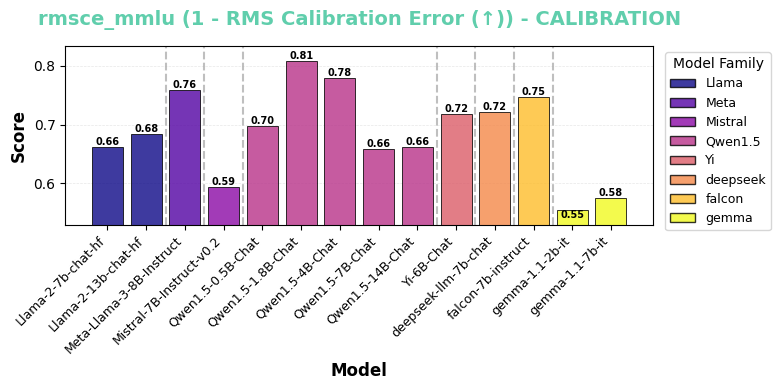

Saved: ./imgs/scores_per_model/scores_jailbreaks_avg.png


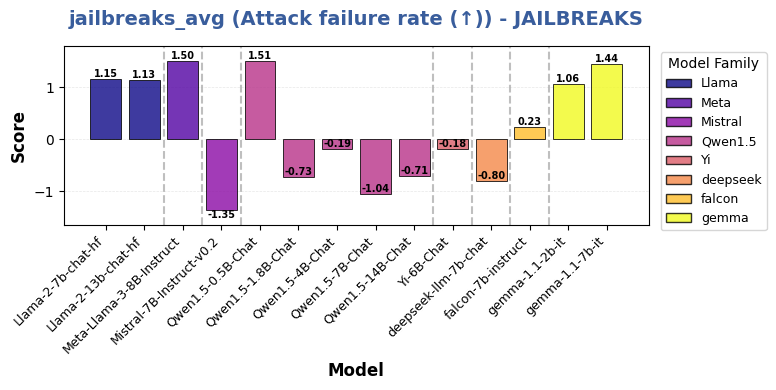

In [17]:
def plot_scores_per_model(df_safety, safety_category=None, figsize=(14, 5), category_cmap=None,
                          save_dir=None, y_padding=0.1, metric_info=None):
    """
    Plot scores for each safety metric with models on x-axis.
    Models are grouped by family and ordered by num_params within family.
    
    Parameters:
    -----------
    df_safety : DataFrame
        DataFrame with model column and safety metric columns
    safety_category : dict, optional
        Mapping of metric names to safety categories (for coloring)
    figsize : tuple
        Figure size for each plot
    save_dir : str, optional
        Directory to save plots (if None, won't save)
    y_padding : float
        Padding factor for y-axis (0.1 = 10% padding above and below)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    
    # Get columns to plot (exclude model and num_params)
    cols_to_plot = [col for col in df_safety.columns 
                    if col not in ['model', 'num_params']]
    
    # Extract model family (first part of model name)
    df_plot = df_safety.copy()
    df_plot['family'] = df_plot['model'].str.split(r'[-\s]').str[0]
    
    # Sort by family, then by num_params if available
    if 'num_params' in df_plot.columns:
        df_plot = df_plot.sort_values(['family', 'num_params'], ascending=[True, True])
    else:
        df_plot = df_plot.sort_values('family')
    
    # Create color palette for families
    families = df_plot['family'].unique()
    # family_colors = plt.cm.tab10(np.linspace(0, 1, len(families)))
    # family_colors = plt.cm.magma(np.linspace(0, 1, len(families)))
    family_colors = plt.cm.plasma(np.linspace(0, 1, len(families)))
    family_color_map = dict(zip(families, family_colors))
    
    # Define category colors for titles
    # category_colors_title = {
    #     "Ethics": "#5B8DBE",
    #     "Jailbreaks": "#E74C3C",
    #     "Bias": "#27AE60",
    #     "Calibration": "#9B59B6"
    # }
    # Use category_cmap for category colors in titles
    if category_cmap is None:
        print(" setting basic map")
        category_cmap = plt.cm.tab10(np.linspace(0, 1, 4))  

    category_colors_title = {
        "Ethics": category_cmap[0],
        "Jailbreaks": category_cmap[1],
        "Bias": category_cmap[2],
        "Calibration": category_cmap[3]
    }
    
    # Create a plot for each metric
    for col in cols_to_plot:
        fig, ax = plt.subplots(figsize=figsize)
        
        # Get data for this column
        plot_data = df_plot[['model', 'family', col]].copy()
        
        # Remove NaN values for y-axis scaling
        valid_data = plot_data[col].dropna()
        
        if len(valid_data) == 0:
            print(f"Skipping {col} - no valid data")
            plt.close()
            continue
        
        # Calculate y-axis range with padding
        y_min = valid_data.min()
        y_max = valid_data.max()
        y_range = y_max - y_min
        
        # Add padding
        if y_range > 0:
            y_bottom = y_min - (y_range * y_padding)
            y_top = y_max + (y_range * y_padding)
        else:
            # If all values are the same, add fixed padding
            y_bottom = y_min - 0.1
            y_top = y_max + 0.1
        
        # Create bars with family colors
        x_pos = np.arange(len(plot_data))
        colors = [family_color_map[family] for family in plot_data['family']]
        bars = ax.bar(x_pos, plot_data[col], color=colors, alpha=0.8, 
                      edgecolor='black', linewidth=0.7)
        
        # Add vertical lines between different families
        prev_family = None
        for i, family in enumerate(plot_data['family']):
            if prev_family is not None and family != prev_family:
                ax.axvline(x=i - 0.5, color='gray', linestyle='--', 
                          linewidth=1.5, alpha=0.5, zorder=0)
            prev_family = family
        
        # Customize plot
        ax.set_xlabel('Model', fontsize=12, fontweight='bold')
        ax.set_ylabel('Score', fontsize=12, fontweight='bold')
        
        # Add category to title if available
        title = f'{col}'
        title_color = 'black'
        if safety_category and col in safety_category:
            category = safety_category[col]
            if metric_info and col in metric_info and metric_info[col]:
                title = f'{col} ({metric_info[col]})'
            else:
                print(f"Metric info not found for {col}, using column name as title.")
            title += f' - {category.upper()}'
            title_color = category_colors_title.get(category, 'black')
        
        ax.set_title(title, fontsize=14, fontweight='bold', pad=15, color=title_color)
        
        # Set x-axis labels
        ax.set_xticks(x_pos)
        ax.set_xticklabels(plot_data['model'], rotation=45, ha='right', fontsize=9)
        
        # Set y-axis range
        ax.set_ylim(y_bottom, y_top)
        
        # Add grid for better readability
        ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
        ax.set_axisbelow(True)
        
        # Add value labels on top of bars
        for i, (idx, row) in enumerate(plot_data.iterrows()):
            value = row[col]
            if not np.isnan(value):
                # Position label slightly above or below bar depending on space
                va = 'bottom' if value > y_bottom + 0.1 * y_range else 'top'
                ax.text(i, value, f'{value:.2f}', 
                       ha='center', va=va, fontsize=7, fontweight='bold')
        
        # Create legend for families
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=family_color_map[family], 
                                label=family, alpha=0.8, edgecolor='black')
                          for family in families]
        ax.legend(handles=legend_elements, loc='upper left', 
                 bbox_to_anchor=(1.01, 1), title='Model Family', 
                 frameon=True, fontsize=9, title_fontsize=10)
        
        plt.tight_layout()
        
        # Save if directory provided
        if save_dir:
            import os
            os.makedirs(save_dir, exist_ok=True)
            fig_path = os.path.join(save_dir, f'scores_{col}.png')
            plt.savefig(fig_path, dpi=300, bbox_inches='tight')
            print(f"Saved: {fig_path}")
        
        plt.show()
        plt.close()

# category_cmap='viridis'

# category_cmap = plt.get_cmap(category_cmap)(np.linspace(0, 1, 4+1))

# category_cmap = category_cmap[::-1]  # Reverse to match order
# Example usage:
plot_scores_per_model(df_safety_filtered, safety_category=safety_category, metric_info=metric_info, category_cmap=category_cmap,
                      save_dir="./imgs/scores_per_model/",figsize=(8, 4))

## Load Capabilities Scores


In [18]:
path_cap_scores_chat = "./data/model_cap_scores_Chat.json"

import json
with open(path_cap_scores_chat, "r") as f:
    model_cap_dict_chat = json.load(f)


# Add the capability scores to df_safety_filtered
df_safety_filtered['capability_score'] = df_safety_filtered['model'].map(model_cap_dict_chat)
# df_safety_filtered.head()

In [22]:
display(df_safety_filtered)

,model,machiavelli,sycophancy,bbq,crows_pair,discrim_eval,rmsce_mmlu,jailbreaks_avg,num_params,capability_score
0,Llama-2-13b-chat-hf,100.794057,0.177698,0.086131,-4.530920,0.4581,0.683182,1.129884,13.0,-0.777044
1,Llama-2-7b-chat-hf,103.352781,0.279891,0.089995,-4.508179,0.3587,0.661609,1.148290,7.0,-1.858566
2,Meta-Llama-3-8B-Instruct,101.619176,0.100662,0.076284,-4.044005,0.2189,0.758051,1.496652,8.0,1.095007
3,Mistral-7B-Instruct-v0.2,99.197031,0.109115,0.113520,-4.454751,0.3632,0.594428,-1.353966,7.0,0.721326
4,Qwen1.5-0.5B-Chat,103.473520,0.379222,0.143438,-5.899403,0.0584,0.696943,1.508076,0.5,-7.563784
5,Qwen1.5-1.8B-Chat,100.032976,0.267778,0.112562,-6.433343,0.1977,0.808509,-0.732123,1.8,-4.540965
6,Qwen1.5-14B-Chat,103.364543,0.104855,0.239315,-7.355860,0.5967,0.661371,-0.710073,14.0,-0.646676
7,Qwen1.5-4B-Chat,103.562037,0.160960,0.129043,-5.141886,0.2177,0.778407,-0.189279,4.0,-3.442093
8,Qwen1.5-7B-Chat,107.864437,0.126019,0.276482,-9.407151,0.2402,0.659129,-1.041868,7.0,-2.328276
9,Yi-6B-Chat,102.733469,0.207048,0.101621,-8.010290,0.1978,0.718676,-0.182492,6.0,-0.673469


In [23]:
import json

file_name_combi = "./data/model_features_metrics_Combi.json"
# Save df_safety_filtered to JSON file
with open(file_name_combi, 'w') as f:
    json.dump(df_safety_filtered.to_dict(orient='records'), f, indent=2)

print(f"Saved df_safety_filtered to {file_name_combi}")

def load_model_features_metrics(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return pd.DataFrame(data)

Saved df_safety_filtered to ./data/model_features_metrics_Combi.json


### Obtain ranking per Metric


In [24]:
def rank_metrics_per_column(df):
    """
    Returns a new DataFrame where each metric column (except 'model') is replaced by its rank.
    Lower values get lower ranks (rank 1 = best).
    Rows with the same value receive the same rank.
    NaN values are kept as NaN.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'model' column and metric columns.

    Returns:
    --------
    df_ranked : pd.DataFrame
        DataFrame with same columns, but metric columns replaced by ranks.
    """
    df_ranked = df.copy()
    metric_cols = [col for col in df.columns if col != 'model']
    for col in metric_cols:
        # Rank in descending order (rank 1 = best), using 'average' method for ties
        df_ranked[col] = df[col].rank(method='average', ascending=False)
    return df_ranked

# Example usage:
df_ranked = rank_metrics_per_column(df_safety_filtered)
display(df_ranked)

,model,machiavelli,sycophancy,bbq,crows_pair,discrim_eval,rmsce_mmlu,jailbreaks_avg,num_params,capability_score
0,Llama-2-13b-chat-hf,12.0,7.0,12.0,6.0,3.0,8.0,5.0,2.0,6.0
1,Llama-2-7b-chat-hf,7.0,3.0,10.0,5.0,6.0,9.0,4.0,6.5,8.0
2,Meta-Llama-3-8B-Instruct,10.0,14.0,14.0,2.0,8.0,3.0,2.0,3.0,1.0
3,Mistral-7B-Instruct-v0.2,14.0,12.0,7.0,4.0,4.0,12.0,14.0,6.5,2.0
4,Qwen1.5-0.5B-Chat,5.0,2.0,5.0,8.0,14.0,7.0,1.0,14.0,14.0
5,Qwen1.5-1.8B-Chat,13.0,4.0,8.0,10.0,11.0,1.0,11.0,13.0,13.0
6,Qwen1.5-14B-Chat,6.0,13.0,3.0,12.0,2.0,10.0,10.0,1.0,4.0
7,Qwen1.5-4B-Chat,4.0,8.0,6.0,7.0,9.0,2.0,9.0,11.0,10.0
8,Qwen1.5-7B-Chat,1.0,10.0,2.0,14.0,7.0,11.0,13.0,6.5,9.0
9,Yi-6B-Chat,8.0,6.0,9.0,13.0,10.0,6.0,8.0,10.0,5.0
